### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Connecting to the SQL Database

In [5]:
import sqlite3
connection = sqlite3.connect(r"C:\Users\doubl\NordexShiftOptimizationSystem\ShiftData.db")
Shift_Data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


### Basic Dataset Overview
* Shift_Data.columns - List the column names inthe dataset
* Shift_Data.shape - getting the shape of the dataset
* Format the data to proper date format
* df.duplicated().sum() - Checking for duplicates in the dataset
* df.isna().sum() - Checking for missing values in the dataset
* df.describe() - Checking the statistical distribution of our dataset 

In [6]:
Shift_Data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [7]:
Shift_Data.shape

(296334, 31)

In [8]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

### Formating Columns with datatype of Date into proper datetime format

In [16]:
Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['timestamp'] = pd.to_datetime(Shift_Data['timestamp'])

In [17]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

### Checking for Duplicates

In [12]:
Shift_Data.duplicated().sum()

np.int64(0)

### Checking for missing values

In [13]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

### Checking Statistical Distribution

In [14]:
Shift_Data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000
mean,2.048142,2026-05-26 14:23:06.478770688,2026-05-26 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118
min,1.000000,2026-05-26 06:00:00,2026-05-26 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000
25%,1.000000,2026-05-26 06:00:00,2026-05-26 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000
50%,2.000000,2026-05-26 14:00:00,2026-05-26 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000
75%,3.000000,2026-05-26 22:00:00,2026-05-26 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000
max,3.000000,2026-05-26 22:00:00,2026-05-26 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084


### Filling the missing values
* df.isna().sum() - identify the colums that has missing values and show how many values are missing
* df.sort_values(by="date") -  sort  the dataset chronologically, which is essential for timeseries before suing the forward of filling missing values
* Filling the missing values with the last known values , and any other gap that remains filled with the mean.

In [18]:
Shift_Data = Shift_Data.sort_values(by='date')

# Fill temparature & humidity columns
Shift_Data["temperature"] = Shift_Data["temperature"].fillna(method="ffill").fillna(Shift_Data["temperature"].mean())
Shift_Data["humidity"] = Shift_Data["humidity"].fillna(method="ffill").fillna(Shift_Data["humidity"].mean())

# Fill Timestamp
Shift_Data["timestamp"] = Shift_Data["timestamp"].fillna(method="ffill")

C:\Users\doubl\AppData\Local\Temp\ipykernel_24592\3713618238.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data["temperature"] = Shift_Data["temperature"].fillna(method="ffill").fillna(Shift_Data["temperature"].mean())
C:\Users\doubl\AppData\Local\Temp\ipykernel_24592\3713618238.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data["humidity"] = Shift_Data["humidity"].fillna(method="ffill").fillna(Shift_Data["humidity"].mean())
C:\Users\doubl\AppData\Local\Temp\ipykernel_24592\3713618238.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data["timestamp"] = Shift_Data["timestamp"].fillna(method="ffill")


In [19]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [20]:
# Fill the categorical fields
Shift_Data["issue_type"] = Shift_Data["issue_type"].fillna("No issue")
Shift_Data["resolved_by"] = Shift_Data["resolved_by"].fillna("No Maintenance")

#Fill the downtime column
Shift_Data["maintenance_downtime"] = Shift_Data["maintenance_downtime"].fillna(0)

Shift_Data = Shift_Data.drop(columns=["maintenance_id"])


In [23]:
Shift_Data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

# Exploratory Data Analysis

##### Numerical Variables Analysis


* Created histograms to visualize the distribution of all numerical columns (units produced, defects, cycle time, efficiency, runtime, downtime,temperature,humidity)
* Generated boxplots to identify outliers and understand data spread for each numerical variable 

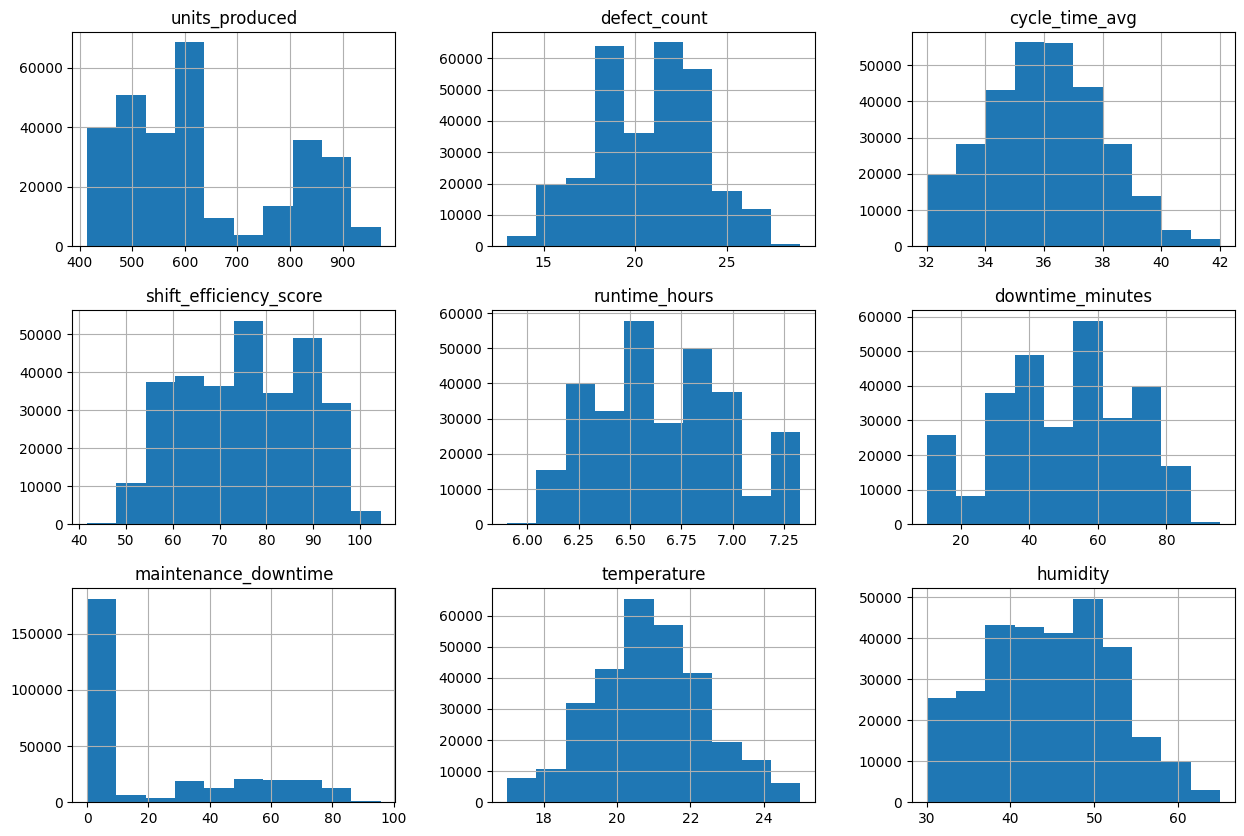

In [24]:

num_cols = [
    "units_produced", "defect_count", "cycle_time_avg",
    "shift_efficiency_score", "runtime_hours", "downtime_minutes", "maintenance_downtime",
    "temperature", "humidity"
]

Shift_Data[num_cols].hist(figsize=(15, 10))
plt.tight_layout
plt.show()

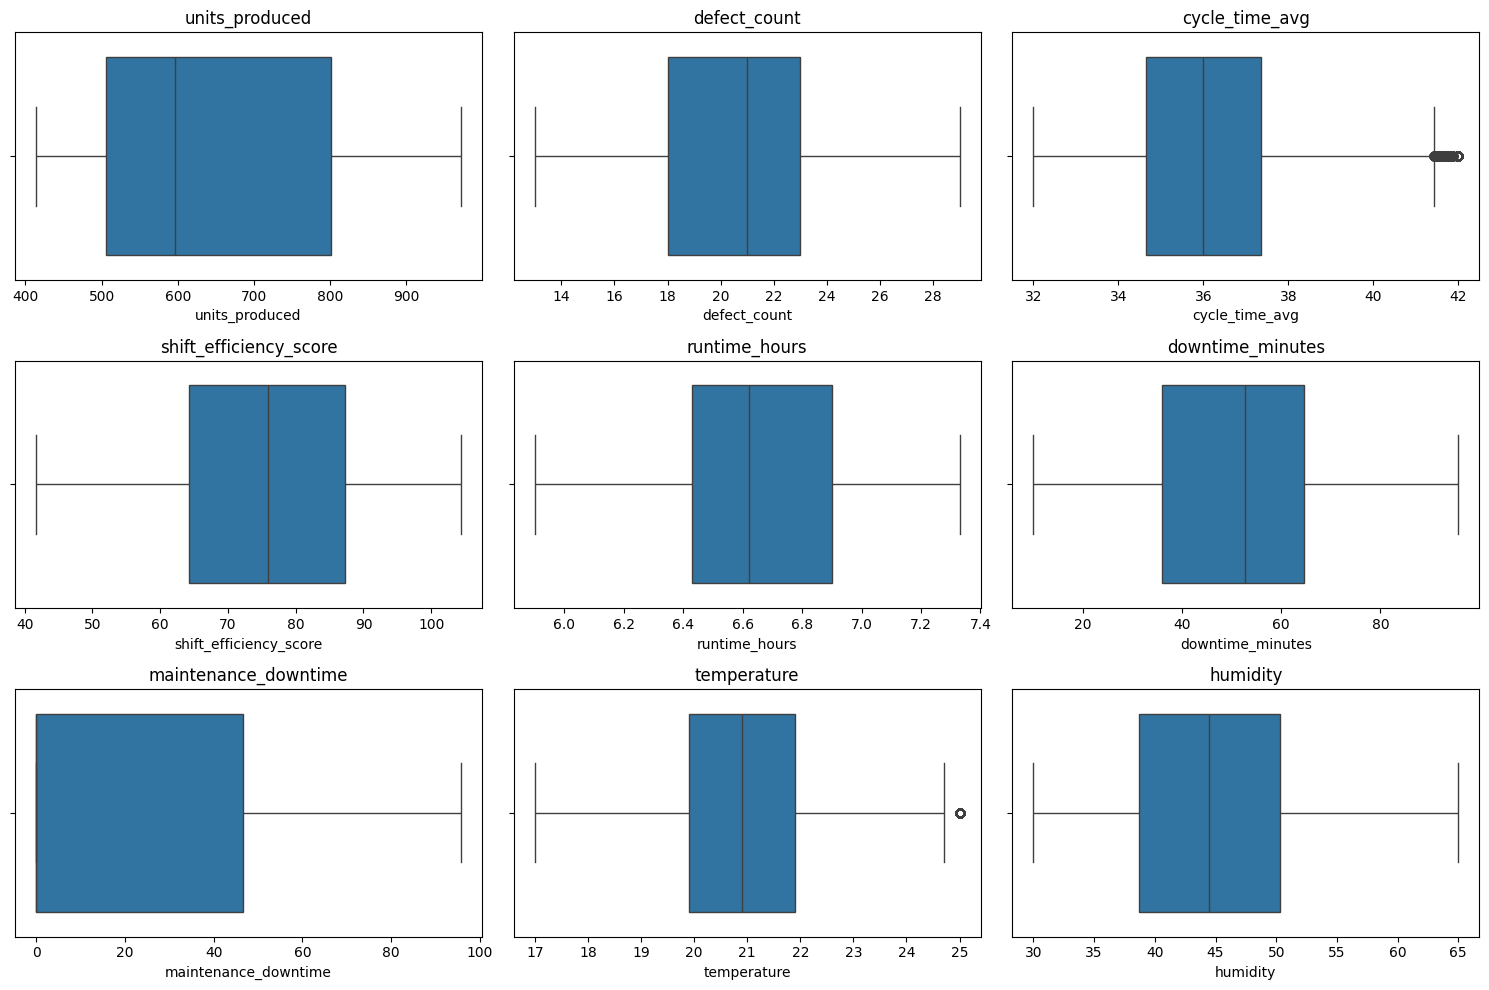

In [26]:
## Using boxplot if our dataset has outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=Shift_Data[col])
    plt.title(col)

plt.tight_layout()
plt.show()


##### Categorical Variable Analysis

* Displayed value counts for all categorical columns (shift name, experience level, skill category, machine status, issue type, defect type, severity, inspection result)
* Created bar charts in a 4x2 grid layout to visualize the frequency distribution of each categorical variable

In [30]:
Categorical_cols = ["shift_name", "issue_type", "resolved_by", "machine_status",
                    "defect_type", "inspection_result", "severity", "experience_level"
                    ]
for column in Categorical_cols:
    print(f"value counts for {column}:\n")
    print (Shift_Data[column].value_counts())

value counts for shift_name:

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
value counts for issue_type:

issue_type
No issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
value counts for resolved_by:

resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07            12427
TECH_08            12290
TECH_02            12065
TECH_10            11977
TECH_05            11743
TECH_04            11275
TECH_01            10522
TECH_09            10441
TECH_06             9954
Name: count, dtype: int64
value counts for machine_status:

machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
value counts for defect_type:

defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
value counts for inspection_result:

inspec

C:\Users\doubl\AppData\Local\Temp\ipykernel_24592\2616538215.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette='coolwarm', ax=axes[index])
C:\Users\doubl\AppData\Local\Temp\ipykernel_24592\2616538215.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette='coolwarm', ax=axes[index])
C:\Users\doubl\AppData\Local\Temp\ipykernel_24592\2616538215.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette='coolwarm', ax=axes[index]

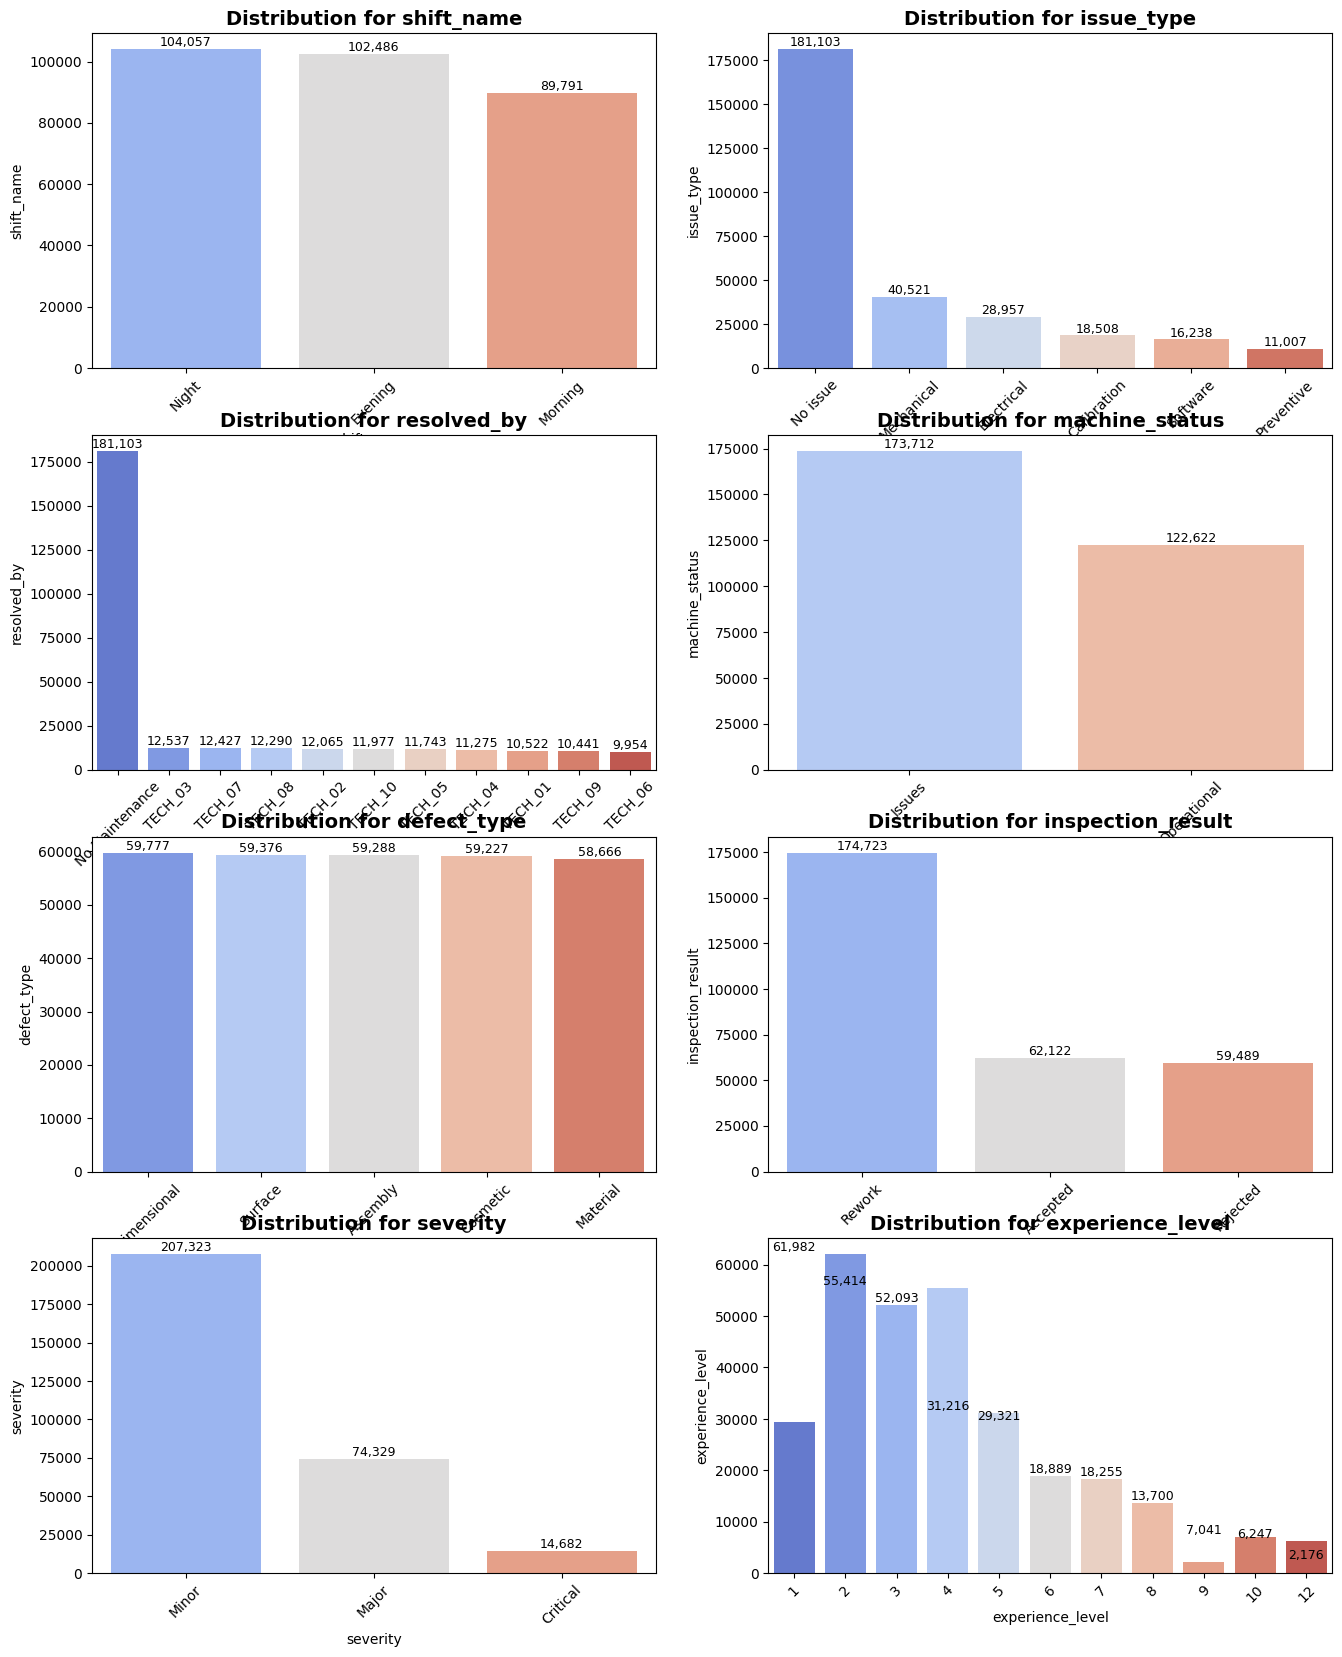

In [34]:
fig, axes = plt.subplots(4, 2, figsize=(16,20))

axes = axes.flatten()

for index, column in enumerate(Categorical_cols):
    # Get the value counts
    counts = Shift_Data[column].value_counts().reset_index()

    sns.barplot(data=counts, x=column, y='count', palette='coolwarm', ax=axes[index])
    axes[index].tick_params (axis='x', rotation =45)
    axes[index].set_title(f"Distribution for {column}", fontsize=14, fontweight='bold')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel(column)

    #add the value labels on the bar
    for j, v in enumerate(counts['count']):
        axes[index].text(j, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout
plt.show()

##### Maintenance Flag Analysis

* Grouped numerical metrics by maintenance flag (0 = no maintenance, 1 = maintenance performed)
* Created grouped bar charts comparing al metrics between the two maintenance flag categories.

##### Operational Performance during Maintenance vs No Maintenance

In [36]:
Shift_Data["maintenance_flag"].value_counts()

maintenance_flag
0    242487
1     53847
Name: count, dtype: int64

In [38]:
# Maintenance Flag Analysis
maintenance_data = Shift_Data.groupby("maintenance_flag")[num_cols].mean()

In [39]:
maintenance_data.head()

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,53.701075,20.860356,44.613007


AttributeError: module 'matplotlib.pyplot' has no attribute 'xtick'

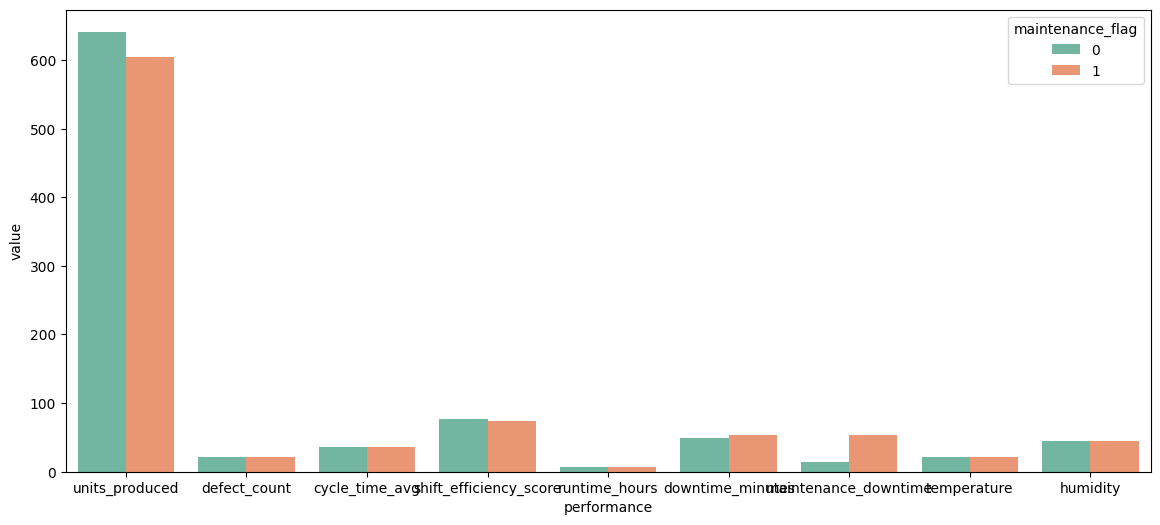

In [44]:
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars= ["maintenance_flag"],
    var_name="performance",
    value_name= 'value'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data = maintenance_plot_melt,
    x = "performance",
    y = "value",
    hue = "maintenance_flag",
    palette= 'Set2'
)

plt.xtick(rotation = 45, ha='right')
plt.title("Performance Based on Maintenance")
plt.legend(title = "Maintenance Flag")
plt.tight_layout()
plt.show()

##### Shift Performance Analysis

* Aggregated key performance indicators by shift (average units, total units, cycle time, defects, downtime, efficiency)
* Calculated defect rate for each shift (total defects / total units produced)
* Visualized shift KPIs using bar charts in a 2x3 grid layout

In [46]:
shift_performance_data = Shift_Data.groupby("shift_name").agg({
    "units_produced": ["mean", "sum"],
    "cycle_time_avg": "mean",
    "defect_count": "mean",
    "downtime_minutes": ["mean", "sum"],
    "shift_efficiency_score": "mean"
}).reset_index()

shift_performance_data.columns = [
    "shift_name", "average_units_produced", "total_units_produced",
    "average_cycle_time", "average_defect_count", "average_downtime", "total_downtime",
    "average_efficiency"
]

# calculate defect rate
defect_sum = Shift_Data.groupby("shift_name")["defect_count"].sum().values
unit_sum =Shift_Data.groupby("shift_name")["units_produced"].sum().values

shift_performance_data["defect_rate"] = (defect_sum/unit_sum) * 100

shift_performance_data.sort_values(by="average_units_produced", ascending = False)

,shift_name,average_units_produced,total_units_produced,average_cycle_time,average_defect_count,average_downtime,total_downtime,average_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


In [65]:
output_per_hour_data = output_per_hour.reset_index()

fig, axes = plt.subplots(2, 4, figsize=(15, 10))

axes = axes.flatten()

metrics = ["average_units_produced", "total_units_produced", "average_cycle_time", "average_defect_count", "average_downtime", "total_downtime",
           "average_efficiency", "defect_rate"]

for i, metric in enumerate(metrics):
    sns.barplot(data = shift_performance_data,
                x = 'shift_name',
                y = metric,
                hue = "shift_name",
                palette = "Set2",
                legend = False,
                ax =axes[i])
    axes[i].set_title(f"{metric.replace("_", " ").title()}", fontsize=12, fontweight= "bold")
    axes[i].set_xlabel("Shift Name")
    axes[i].set_ylabel(metric.replace("_", " ").title())

    for j, v in enumerate(shift_performance_data[metric]):
        if 'units' in metric:
            axes[i].text(j, v, f'{v:,.0f}', ha="center", va="bottom", fontsize = 9)
        else:
            axes[i].text(j, v, f'{v:,.2f}', ha = "center", va ="bottom", fontsize = 9)

plt.subtitle("Shift Performance Across Board", fontsize = 16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



AttributeError: 'numpy.float64' object has no attribute 'reset_index'

##### Productivity Metrics

* Created a new feature: total machine hours (runtime hours + downtime minutes converted to hours)
* Calculated output per hour for each shift (total units produced / machine hours)
* Compared output per hour against average efficiency scores across shifts 

##### Shift Performance based on production output per hour

In [70]:
Shift_Data["total_operation_hours"] = Shift_Data["runtime_hours"] + (Shift_Data["downtime_minutes"]/60)

output_per_hour = (
    Shift_Data.groupby("shift_name")
    .apply(lambda x:x["units_produced"].sum() / x["total_operation_hours"].sum())
    .rename("output_per_hour")
)
output_per_hour

C:\Users\doubl\AppData\Local\Temp\ipykernel_24592\3666435840.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:x["units_produced"].sum() / x["total_operation_hours"].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
Name: output_per_hour, dtype: float64

In [71]:
output_per_hour_data = output_per_hour.reset_index()

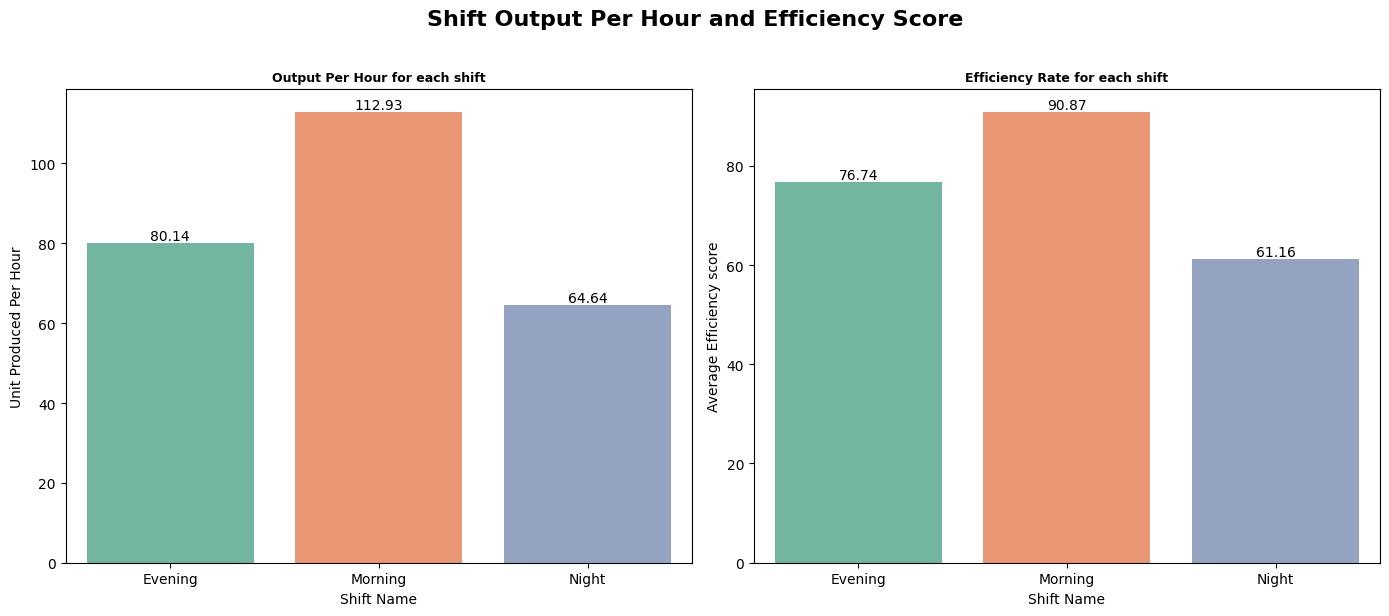

In [74]:


fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.barplot(
    data = output_per_hour_data,
    x = "shift_name",
    y = 'output_per_hour',
    hue = "shift_name",
    palette = "Set2",
    ax = axes[0],
    legend = False
)

axes[0].set_title("Output Per Hour for each shift", fontsize = 9, fontweight = 'bold')
axes[0].set_xlabel("Shift Name")
axes[0].set_ylabel("Unit Produced Per Hour")
for i, v, in enumerate(output_per_hour_data['output_per_hour']):
    axes[0].text(i, v, f'{v:.2f}', ha = "center", va = "bottom")

merged_data = shift_performance_data.merge(output_per_hour_data, on = "shift_name")
# Plot 2, plotting the Shift Efficiency Score

sns.barplot(
    data = merged_data,
    x = "shift_name",
    y = 'average_efficiency',
    hue = "shift_name",
    palette = "Set2",
    ax = axes[1],
    legend = False
)

axes[1].set_title("Efficiency Rate for each shift", fontsize = 9, fontweight = 'bold')
axes[1].set_xlabel("Shift Name")
axes[1].set_ylabel("Average Efficiency score")

for i, v, in enumerate(merged_data['average_efficiency']):
    axes[1].text(i, v, f'{v:.2f}', ha = "center", va = "bottom")

plt.suptitle("Shift Output Per Hour and Efficiency Score", fontsize = 16, fontweight = "bold", y=1.02)
plt.tight_layout()
plt.show()

## OEE Calculation

The code calculates Overall Equipment Effectiveness(OEE) by:
1. Separatiing Production and Machine Data - Creates distinct tables for production metrics (units, defects) and machine metrics (downtime).
2. Computing Three OEE Components:
* Availablity - Machine uptime percentage
* Performance - Speed efficiency vs theoretical maximum
* Quality - Percentage of defect-free units
3. Tracking monthly trends - Calculates OEE per month and defines performance degradationbetween months

Why this matters: OEE is a manufacturing industry standard that depicts whether productivity losses come from equipment downtime, slow operation speeds, or product defects.

##### Availability Analysis

* Calculated machine availability for each shift (runtime hours / total available time)
* Availability represents the percentage of time machines were actually running versus total scheduled production time
* Visualized availability by shift with percentage labels

In [76]:
production = (
    Shift_Data[["production_id", "shift_id", "date", "units_produced", "defect_count"]]
    .drop_duplicates(subset=["production_id"])
    .copy()
)

machine = (
    Shift_Data[["machine_id", "date", "shift_id", "downtime_minutes"]]
    .drop_duplicates()
    .copy()
)

In [77]:
production.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [79]:
production.shape

(13650, 5)

In [78]:
machine.head()

,machine_id,date,shift_id,downtime_minutes
0,MC_001,2024-01-01,1,15.39
2308,MC_002,2024-01-01,3,53.73
2309,MC_003,2024-01-01,3,51.90
2331,MC_004,2024-01-01,3,54.45
2281,MC_001,2024-01-01,3,52.99


In [80]:
machine.shape

(13650, 4)

##### OEE Metrics Calculation

In [82]:
import os

PLANNED = globals().get('PLANNED_H', 7.5)
THEO = globals().get('THEO_RATE', 100.0)

### computing per machine availabilty
machine['available_machine'] = 1 - machine['downtime_minutes']/(PLANNED *60)
machine['available_machine'] = machine["available_machine"].clip(0, 1)

available_machine_agg = (
    machine.groupby(['date', 'shift_id'])['available_machine']
    .mean()
    .reset_index()
    .rename(columns={'available_machine': 'machine_availability'})
)

In [83]:
available_machine_agg.head()

,date,shift_id,machine_availability
0,2024-01-01,1,0.963687
1,2024-01-01,2,0.920976
2,2024-01-01,3,0.881807
3,2024-01-02,1,0.965439
4,2024-01-02,2,0.919042


In [84]:
available_machine_agg.shape

(273, 3)

In [94]:
# merging availability into production
merged_production_data = production.merge(available_machine_agg, how="left", on=["date", "shift_id"])
merged_production_data['machine_availability'] = merged_production_data['machine_availability'].fillna(1)

# performance based on a planned time (not run time)
merged_production_data = (merged_production_data['units_produced'] / (THEO * PLANNED)).clip(0, 1)

# Quality
merged_production_data["quality"] = 1 - merged_production_data["defect_count"] / merged_production_data["units_produced"]
merged_production_data["quality"] = merged_production_data["quality"].fillna(1).clip(0, 1)

# Final OEE estimate
merged_production_data['oee_est'] = merged_production_data['machine_availability'] * merged_production_data["performance"] * merged_production_data["quality"]

merged_production_data['month'] = merged_production_data['date'].dt.month

KeyError: 'defect_count'

In [ ]:
merged_production_data.head()